Mounted at /content/drive
GPU Detected: /physical_device:GPU:0
Adjusted dataset path → /content/final_dataset/final_dataset

Dataset extracted successfully
Found 920 images belonging to 3 classes.
Found 230 images belonging to 3 classes.

CLASS WEIGHTS
{0: np.float64(0.7666666666666667), 1: np.float64(0.7666666666666667), 2: np.float64(2.5555555555555554)}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

MODEL SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,219,046 (16.09 MB)

 Trainable params: 166,915 (652.01 KB)

 Non-trainable params: 4,052,131 (15.46 MB)


PHASE 1 — TRAINING TOP LAYERS
Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 936ms/step - accuracy: 0.5984 - loss: 1.1766
Epoch 1: val_accuracy improved from None to 0.79130, saving model to /content/drive/MyDrive/Video_Model/visual_emotion_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Video_Model/visual_emotion_model.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.7120 - loss: 0.9996 - val_accuracy: 0.7913 - val_loss: 0.6073 - learning_rate: 0.0010
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 0.7661 - loss: 0.7780
Epoch 2: val_accuracy improved from 0.79130 to 0.90000, saving model to /content/drive/MyDrive/Video_Model/visual_emotion_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Video_Model/visual_emotion_model.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 45s 774ms/step - accuracy: 0.7913 - loss: 0.7460 - val_accuracy: 0.9000 - val_loss: 0.5294 - learning_rate: 0.0010
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - ac

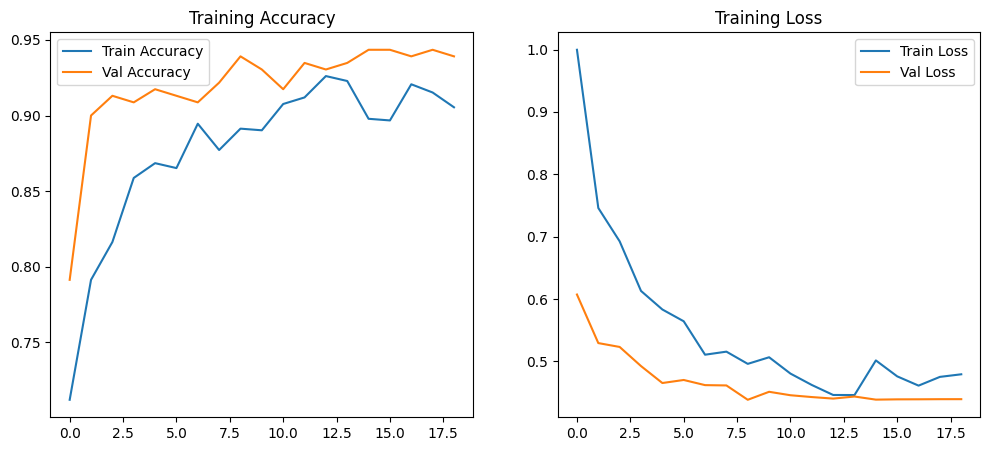


MODEL TRAINING COMPLETED

Saved Files:
1. visual_emotion_model.keras
2. visual_class_names.npy
3. training_curves.png


In [1]:
# =========================================================
# INFANT VISUAL EMOTION MODEL
# FINAL PROFESSIONAL VERSION
# =========================================================
#
# CLASSES:
# distressed
# normal
# sleepy
#
# MODEL:
# EfficientNetB0
#
# FEATURES:
# ✅ Transfer Learning
# ✅ Fine-Tuning
# ✅ Label Smoothing
# ✅ Class Weights
# ✅ Data Augmentation
# ✅ Best Checkpoint Saving
# ✅ Separate LR Scheduler
# ✅ Saved Training Curves
#
# =========================================================

# =========================================================
# STEP 1 — INSTALL LIBRARIES
# =========================================================

!pip install -q tensorflow

# =========================================================
# STEP 2 — MOUNT GOOGLE DRIVE
# =========================================================

from google.colab import drive

drive.mount('/content/drive')

# =========================================================
# STEP 3 — IMPORTS
# =========================================================

import os
import zipfile
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.models import (
    Sequential,
    load_model
)

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator
)

# =========================================================
# STEP 4 — GPU CHECK
# =========================================================

gpus = tf.config.list_physical_devices('GPU')

if gpus:

    print(f"GPU Detected: {gpus[0].name}")

else:

    print("WARNING: No GPU detected")
    print("Runtime → Change runtime type → T4 GPU")

# =========================================================
# STEP 5 — ZIP DATASET PATH
# =========================================================

ZIP_PATH = (
    "/content/drive/MyDrive/"
    "Video_Model/"
    "final_dataset.zip"
)

# =========================================================
# STEP 6 — EXTRACT DATASET
# =========================================================

EXTRACT_PATH = "/content/final_dataset"

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:

    zip_ref.extractall(EXTRACT_PATH)

# ---------------------------------------------------------
# HANDLE EXTRA SUBFOLDER
# ---------------------------------------------------------

subdirs = [

    d for d in os.listdir(EXTRACT_PATH)

    if os.path.isdir(
        os.path.join(EXTRACT_PATH, d)
    )
]

if len(subdirs) == 1:

    EXTRACT_PATH = os.path.join(
        EXTRACT_PATH,
        subdirs[0]
    )

    print(
        f"Adjusted dataset path → "
        f"{EXTRACT_PATH}"
    )

print("\nDataset extracted successfully")

# =========================================================
# STEP 7 — CONFIGURATION
# =========================================================

IMAGE_SIZE = 240

BATCH_SIZE = 16

EPOCHS = 20

FINETUNE_EPOCHS = 10

NUM_CLASSES = 3

SEED = 42

MODEL_SAVE_PATH = (

    "/content/drive/MyDrive/"
    "Video_Model/"
    "visual_emotion_model.keras"
)

PLOT_SAVE_PATH = (

    "/content/drive/MyDrive/"
    "Video_Model/"
    "training_curves.png"
)

CLASS_NAMES = [

    "distressed",
    "normal",
    "sleepy"
]

# =========================================================
# STEP 8 — DATA AUGMENTATION
# =========================================================

train_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input,

    validation_split=0.2,

    rotation_range=10,

    zoom_range=0.15,

    width_shift_range=0.1,

    height_shift_range=0.1,

    horizontal_flip=True
)

# ---------------------------------------------------------
# VALIDATION GENERATOR
# NO AUGMENTATION
# ---------------------------------------------------------

val_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input,

    validation_split=0.2
)

# =========================================================
# STEP 9 — TRAIN GENERATOR
# =========================================================

train_generator = train_datagen.flow_from_directory(

    EXTRACT_PATH,

    target_size=(
        IMAGE_SIZE,
        IMAGE_SIZE
    ),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training',

    shuffle=True,

    seed=SEED
)

# =========================================================
# STEP 10 — VALIDATION GENERATOR
# =========================================================

val_generator = val_datagen.flow_from_directory(

    EXTRACT_PATH,

    target_size=(
        IMAGE_SIZE,
        IMAGE_SIZE
    ),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation',

    shuffle=False,

    seed=SEED
)

# =========================================================
# STEP 11 — CLASS WEIGHTS
# =========================================================

labels = train_generator.classes

class_weights = compute_class_weight(

    class_weight='balanced',

    classes=np.unique(labels),

    y=labels
)

class_weights = dict(
    enumerate(class_weights)
)

print("\n===================================")
print("CLASS WEIGHTS")
print("===================================")

print(class_weights)

# =========================================================
# STEP 12 — LOAD EFFICIENTNETB0
# =========================================================

base_model = EfficientNetB0(

    weights='imagenet',

    include_top=False,

    input_shape=(
        IMAGE_SIZE,
        IMAGE_SIZE,
        3
    )
)

# ---------------------------------------------------------
# FREEZE PRETRAINED LAYERS
# ---------------------------------------------------------

base_model.trainable = False

# =========================================================
# STEP 13 — BUILD MODEL
# =========================================================

model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    BatchNormalization(),

    Dropout(0.4),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        NUM_CLASSES,
        activation='softmax'
    )
])

# =========================================================
# STEP 14 — COMPILE MODEL (PHASE 1)
# =========================================================

model.compile(

    optimizer='adam',

    loss=tf.keras.losses.CategoricalCrossentropy(

        label_smoothing=0.1
    ),

    metrics=['accuracy']
)

print("\n===================================")
print("MODEL SUMMARY")
print("===================================")

model.summary()

# =========================================================
# STEP 15 — CALLBACKS
# =========================================================

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=3,

    verbose=1
)

checkpoint = ModelCheckpoint(

    MODEL_SAVE_PATH,

    monitor='val_accuracy',

    save_best_only=True,

    verbose=1
)

# =========================================================
# STEP 16 — PHASE 1 TRAINING
# =========================================================

print("\n===================================")
print("PHASE 1 — TRAINING TOP LAYERS")
print("===================================")

history = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=EPOCHS,

    class_weight=class_weights,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

# =========================================================
# STEP 17 — PHASE 2 FINE-TUNING
# =========================================================

print("\n===================================")
print("PHASE 2 — FINE-TUNING")
print("===================================")

# ---------------------------------------------------------
# UNFREEZE TOP 30 LAYERS
# ---------------------------------------------------------

for layer in base_model.layers[-30:]:

    if not isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):

        layer.trainable = True

# =========================================================
# STEP 18 — RECOMPILE MODEL
# =========================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss=tf.keras.losses.CategoricalCrossentropy(

        label_smoothing=0.1
    ),

    metrics=['accuracy']
)

# ---------------------------------------------------------
# FRESH LR SCHEDULER FOR PHASE 2
# ---------------------------------------------------------

finetune_early_stop = EarlyStopping(

    monitor='val_loss',

    patience=4,

    restore_best_weights=True
)

reduce_lr_finetune = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=2,

    verbose=1
)

history_finetune = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=FINETUNE_EPOCHS,

    class_weight=class_weights,

    callbacks=[
        finetune_early_stop,
        reduce_lr_finetune,
        checkpoint
    ]
)

# =========================================================
# STEP 19 — LOAD BEST MODEL
# =========================================================

model = load_model(
    MODEL_SAVE_PATH
)

# =========================================================
# STEP 20 — EVALUATE MODEL
# =========================================================

loss, accuracy = model.evaluate(
    val_generator
)

print("\n===================================")
print("FINAL VALIDATION ACCURACY")
print("===================================")

print(f"Loss     : {loss:.4f}")

print(
    f"Accuracy : "
    f"{accuracy:.4f} "
    f"({accuracy*100:.1f}%)"
)

# =========================================================
# STEP 21 — PREDICTIONS
# =========================================================

predictions = model.predict(
    val_generator
)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

true_classes = val_generator.classes

# =========================================================
# STEP 22 — CLASSIFICATION REPORT
# =========================================================

print("\n===================================")
print("CLASSIFICATION REPORT")
print("===================================")

print(

    classification_report(

        true_classes,

        predicted_classes,

        target_names=CLASS_NAMES
    )
)

# =========================================================
# STEP 23 — CONFUSION MATRIX
# =========================================================

print("\n===================================")
print("CONFUSION MATRIX")
print("===================================")

cm = confusion_matrix(

    true_classes,

    predicted_classes
)

print(cm)

# =========================================================
# STEP 24 — SAVE CLASS NAMES
# =========================================================

np.save(

    "/content/drive/MyDrive/"
    "Video_Model/"
    "visual_class_names.npy",

    CLASS_NAMES
)

# =========================================================
# STEP 25 — COMBINE TRAINING HISTORY
# =========================================================

train_acc = (
    history.history['accuracy']
    +
    history_finetune.history['accuracy']
)

val_acc = (
    history.history['val_accuracy']
    +
    history_finetune.history['val_accuracy']
)

train_loss = (
    history.history['loss']
    +
    history_finetune.history['loss']
)

val_loss = (
    history.history['val_loss']
    +
    history_finetune.history['val_loss']
)

# =========================================================
# STEP 26 — TRAINING CURVES
# =========================================================

plt.figure(figsize=(12,5))

# ---------------------------------------------------------
# ACCURACY
# ---------------------------------------------------------

plt.subplot(1,2,1)

plt.plot(
    train_acc,
    label='Train Accuracy'
)

plt.plot(
    val_acc,
    label='Val Accuracy'
)

plt.legend()

plt.title("Training Accuracy")

# ---------------------------------------------------------
# LOSS
# ---------------------------------------------------------

plt.subplot(1,2,2)

plt.plot(
    train_loss,
    label='Train Loss'
)

plt.plot(
    val_loss,
    label='Val Loss'
)

plt.legend()

plt.title("Training Loss")

# ---------------------------------------------------------
# SAVE PLOT
# ---------------------------------------------------------

plt.savefig(
    PLOT_SAVE_PATH
)

plt.show()

# =========================================================
# STEP 27 — COMPLETED
# =========================================================

print("\n===================================")
print("MODEL TRAINING COMPLETED")
print("===================================")

print("\nSaved Files:")

print("1. visual_emotion_model.keras")
print("2. visual_class_names.npy")
print("3. training_curves.png")

In [2]:
# =========================================================
# FINAL VIDEO EMOTION TESTING PIPELINE
# =========================================================
#
# MODEL:
# visual_emotion_model.keras
#
# INPUT:
# Any baby video
#
# PIPELINE:
#
# Video
#   ↓
# Frame Extraction
#   ↓
# Batch Prediction
#   ↓
# Probability Averaging
#   ↓
# Final Video Emotion
#
# CLASSES:
# distressed
# normal
# sleepy
#
# =========================================================

# =========================================================
# STEP 1 — INSTALL LIBRARIES
# =========================================================

!pip install -q tensorflow opencv-python

# =========================================================
# STEP 2 — MOUNT GOOGLE DRIVE
# =========================================================

from google.colab import drive

drive.mount('/content/drive')

# =========================================================
# STEP 3 — IMPORTS
# =========================================================

import os
import cv2
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import load_model

from tensorflow.keras.applications.efficientnet import (
    preprocess_input
)

# =========================================================
# STEP 4 — CONFIGURATION
# =========================================================

# MUST MATCH TRAINING SIZE
IMAGE_SIZE = 240

FRAME_SKIP = 24

BATCH_SIZE = 16

# =========================================================
# STEP 5 — MODEL PATH
# =========================================================

MODEL_PATH = (

    "/content/drive/MyDrive/"
    "Video_Model/"
    "visual_emotion_model.keras"
)

# =========================================================
# STEP 6 — CLASS NAMES PATH
# =========================================================

CLASS_NAMES_PATH = (

    "/content/drive/MyDrive/"
    "Video_Model/"
    "visual_class_names.npy"
)

# =========================================================
# STEP 7 — VIDEO PATH
# =========================================================

# Upload any video to Colab

VIDEO_PATH = "/content/drive/MyDrive/Video_Model/test/d1.mp4"

# =========================================================
# STEP 8 — CHECK FILES
# =========================================================

required_files = {

    "Model": MODEL_PATH,

    "Class Names": CLASS_NAMES_PATH,

    "Video": VIDEO_PATH
}

missing = []

for label, path in required_files.items():

    if not os.path.exists(path):

        missing.append(f"{label}: {path}")

if len(missing) > 0:

    raise FileNotFoundError(

        "\nMissing Files:\n"
        +
        "\n".join(missing)
    )

print("\nAll required files found")

# =========================================================
# STEP 9 — LOAD CLASS NAMES
# =========================================================

CLASS_NAMES = list(

    np.load(

        CLASS_NAMES_PATH,

        allow_pickle=True
    )
)

print("\nLoaded Class Names:")

print(CLASS_NAMES)

# =========================================================
# STEP 10 — LOAD MODEL
# =========================================================

model = load_model(MODEL_PATH)

print("\nModel loaded successfully")

print(f"Input Shape: {model.input_shape}")

# =========================================================
# STEP 11 — OPEN VIDEO
# =========================================================

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():

    raise ValueError(
        "Could not open video"
    )

# =========================================================
# STEP 12 — VIDEO INFORMATION
# =========================================================

total_frames = int(

    cap.get(cv2.CAP_PROP_FRAME_COUNT)
)

fps = cap.get(cv2.CAP_PROP_FPS)

duration = total_frames / fps

print("\n===================================")
print("VIDEO INFORMATION")
print("===================================")

print(f"Total Frames : {total_frames}")

print(f"FPS          : {fps:.2f}")

print(f"Duration     : {duration:.2f} sec")

# =========================================================
# STEP 13 — PROCESS VIDEO
# =========================================================

frame_count = 0

frames_batch = []

print("\n===================================")
print("PROCESSING VIDEO")
print("===================================")

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_count += 1

    # -----------------------------------------------------
    # SKIP FRAMES
    # -----------------------------------------------------

    if frame_count % FRAME_SKIP != 0:

        continue

    try:

        # -------------------------------------------------
        # CONVERT BGR → RGB
        # -------------------------------------------------

        frame_rgb = cv2.cvtColor(

            frame,

            cv2.COLOR_BGR2RGB
        )

        # -------------------------------------------------
        # RESIZE
        # -------------------------------------------------

        frame_resized = cv2.resize(

            frame_rgb,

            (
                IMAGE_SIZE,
                IMAGE_SIZE
            )
        )

        # -------------------------------------------------
        # CONVERT TO FLOAT ARRAY
        # -------------------------------------------------

        frame_array = np.array(

            frame_resized,

            dtype=np.float32
        )

        # -------------------------------------------------
        # PREPROCESS
        # -------------------------------------------------

        frame_array = preprocess_input(
            frame_array
        )

        # -------------------------------------------------
        # STORE FRAME
        # -------------------------------------------------

        frames_batch.append(
            frame_array
        )

    except Exception as e:

        print(
            f"\nError on frame "
            f"{frame_count}"
        )

        print(e)

# =========================================================
# STEP 14 — RELEASE VIDEO
# =========================================================

cap.release()

# =========================================================
# STEP 15 — CHECK FRAMES
# =========================================================

if len(frames_batch) == 0:

    raise ValueError(
        "No frames processed successfully"
    )

print(

    f"\nFrames Selected: "
    f"{len(frames_batch)}"
)

# =========================================================
# STEP 16 — CONVERT TO NUMPY
# =========================================================

frames_batch = np.array(
    frames_batch
)

print(
    f"Batch Shape: "
    f"{frames_batch.shape}"
)

# =========================================================
# STEP 17 — BATCH PREDICTION
# =========================================================

print("\n===================================")
print("RUNNING MODEL INFERENCE")
print("===================================")

all_predictions = model.predict(

    frames_batch,

    batch_size=BATCH_SIZE,

    verbose=1
)

processed_frames = len(all_predictions)

print(

    f"\nProcessed Frames: "
    f"{processed_frames}"
)

# =========================================================
# STEP 18 — FRAME LEVEL RESULTS
# =========================================================

print("\n===================================")
print("FRAME PREDICTIONS")
print("===================================")

for i, prediction in enumerate(all_predictions):

    predicted_index = np.argmax(
        prediction
    )

    predicted_class = CLASS_NAMES[
        predicted_index
    ]

    confidence = prediction[
        predicted_index
    ]

    print(

        f"Frame {i+1:<4} → "

        f"{predicted_class:<12} "

        f"{confidence:.4f}"
    )

# =========================================================
# STEP 19 — AVERAGE PROBABILITIES
# =========================================================

final_probabilities = np.mean(

    all_predictions,

    axis=0
)

# =========================================================
# STEP 20 — FINAL VIDEO PREDICTION
# =========================================================

final_index = np.argmax(
    final_probabilities
)

final_class = CLASS_NAMES[
    final_index
]

final_confidence = final_probabilities[
    final_index
]

# =========================================================
# STEP 21 — FINAL RESULT
# =========================================================

print("\n===================================")
print("FINAL VIDEO PREDICTION")
print("===================================")

print(f"\nPredicted Class  : {final_class}")

print(
    f"Confidence Score : "
    f"{final_confidence:.4f}"
)

# =========================================================
# STEP 22 — ALL CLASS PROBABILITIES
# =========================================================

print("\n===================================")
print("AVERAGED CLASS PROBABILITIES")
print("===================================")

for i, class_name in enumerate(CLASS_NAMES):

    score = final_probabilities[i]

    bar = "#" * int(score * 30)

    marker = ""

    if i == final_index:

        marker = " <-- predicted"

    print(

        f"{class_name:<15} "

        f"{score:.4f} "

        f"{bar}"

        f"{marker}"
    )

# =========================================================
# STEP 23 — INTERPRETATION
# =========================================================

print("\n===================================")
print("INTERPRETATION")
print("===================================")

if final_class == "distressed":

    print(
        "\nBaby appears emotionally distressed"
    )

elif final_class == "normal":

    print(
        "\nBaby appears calm and emotionally stable"
    )

elif final_class == "sleepy":

    print(
        "\nBaby appears sleepy or drowsy"
    )

# =========================================================
# STEP 24 — CONFIDENCE ANALYSIS
# =========================================================

print("\n===================================")
print("CONFIDENCE ANALYSIS")
print("===================================")

if final_confidence >= 0.85:

    print(
        "\nVery High Confidence Prediction"
    )

elif final_confidence >= 0.70:

    print(
        "\nModerate Confidence Prediction"
    )

else:

    print(
        "\nLow Confidence Prediction"
    )

    print(
        "Possible reasons:"
    )

    print("- unclear baby face")
    print("- mixed emotional states")
    print("- poor lighting")
    print("- blurry video")
    print("- unseen visual pattern")

# =========================================================
# STEP 25 — COMPLETED
# =========================================================

print("\n===================================")
print("VIDEO ANALYSIS COMPLETED")
print("===================================")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

All required files found

Loaded Class Names:
[np.str_('distressed'), np.str_('normal'), np.str_('sleepy')]

Model loaded successfully
Input Shape: (None, 240, 240, 3)

VIDEO INFORMATION
Total Frames : 412
FPS          : 23.98
Duration     : 17.18 sec

PROCESSING VIDEO

Frames Selected: 17
Batch Shape: (17, 240, 240, 3)

RUNNING MODEL INFERENCE
2/2 ━━━━━━━━━━━━━━━━━━━━ 22s 14s/step

Processed Frames: 17

FRAME PREDICTIONS
Frame 1    → sleepy       0.9295
Frame 2    → sleepy       0.8935
Frame 3    → sleepy       0.9304
Frame 4    → sleepy       0.9526
Frame 5    → sleepy       0.9440
Frame 6    → sleepy       0.9166
Frame 7    → sleepy       0.9529
Frame 8    → sleepy       0.9223
Frame 9    → sleepy       0.9705
Frame 10   → sleepy       0.9678
Frame 11   → sleepy       0.9585
Frame 12   → sleepy       0.9527
Frame 13   → sleepy       0.9593
Frame 14   → sl